In [1]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
import zipfile

with zipfile.ZipFile("jena_climate_2009_2016.csv.zip", 'r') as zip_ref:
    zip_ref.extractall("./") 

--2025-03-22 20:12:38--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.173.152, 52.216.32.96, 16.182.105.184, ...
connected. to s3.amazonaws.com (s3.amazonaws.com)|52.217.173.152|:443... 
200 OKequest sent, awaiting response... 
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip.4’

jena_climate_2009_2 100%[===================>]  12.94M  9.86MB/s    in 1.3s    

2025-03-22 20:12:39 (9.86 MB/s) - ‘jena_climate_2009_2016.csv.zip.4’ saved [13565642/13565642]



In [2]:
import os
fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [3]:
import numpy as np
temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))
for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

In [6]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


In [7]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [8]:
import numpy as np
from tensorflow import keras
int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

2025-03-22 20:12:57.736859: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-22 20:12:57.745245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742692377.753372    4740 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742692377.755762    4740 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-22 20:12:57.766024: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


2025-03-22 20:13:00.616887: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


**Instantiating datasets for training, validation, and testing**

In [9]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 48 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

**Inspecting the output of one of our datasets**

In [10]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


**Computing the common-sense baseline MAE**

In [11]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

2025-03-22 20:13:16.046432: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Validation MAE: 3.21
Test MAE: 3.47


**Training and evaluating a densely connected model**

In [12]:
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
#x = layers.Flatten()(inputs) #i was getting errors flattening so I took it out
x = layers.Dense(16, activation="relu")(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10


I0000 00:00:1742692414.815359    4863 service.cc:148] XLA service 0x7f37b0014bd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1742692414.815389    4863 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2025-03-22 20:13:34.827067: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1742692414.855745    4863 cuda_dnn.cc:529] Loaded cuDNN version 90300


 17/819 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 167.4899 - mae: 10.8577    

I0000 00:00:1742692415.088994    4863 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 122.3140 - mae: 9.0128 - val_loss: 67.4654 - val_mae: 6.7564
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 76.5116 - mae: 7.0888 - val_loss: 65.4007 - val_mae: 6.6601
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 75.9820 - mae: 7.0643 - val_loss: 65.5918 - val_mae: 6.6714
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 75.9279 - mae: 7.0623 - val_loss: 65.4722 - val_mae: 6.6654
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 75.8751 - mae: 7.0596 - val_loss: 65.6449 - val_mae: 6.6744
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 75.9372 - mae: 7.0619 - val_loss: 65.4734 - val_mae: 6.6657
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 75.8930 - mae: 7.0595 - val_loss: 65.4031 - val_mae: 6.6620
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 75.9080 - mae: 7.0613 - val_loss: 65.7006 - val_mae: 6.6774
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/st

In [27]:
for x_batch, y_batch in test_dataset.take(1):
    predictions = model.predict(x_batch)
    break
print("Predicted vs. Actual Temperature (48 Hours Ahead):")
for pred, actual in zip(predictions[:10].flatten(), y_batch.numpy()[:10].flatten()):
    print(f"Predicted: {pred:.2f} °C, Actual: {actual:.2f} °C")

Predicted vs. Actual Temperature (48 Hours Ahead):
Predicted: 16.95 °C, Actual: 17.99 °C
Predicted: 16.29 °C, Actual: 21.53 °C
Predicted: 11.47 °C, Actual: 11.64 °C
Predicted: 7.90 °C, Actual: -0.23 °C
Predicted: 11.73 °C, Actual: 20.06 °C
Predicted: 12.75 °C, Actual: 12.06 °C
Predicted: 11.30 °C, Actual: 13.86 °C
Predicted: 17.43 °C, Actual: 9.53 °C
Predicted: 16.10 °C, Actual: 21.20 °C
Predicted: 13.61 °C, Actual: 14.83 °C


**Plotting results**

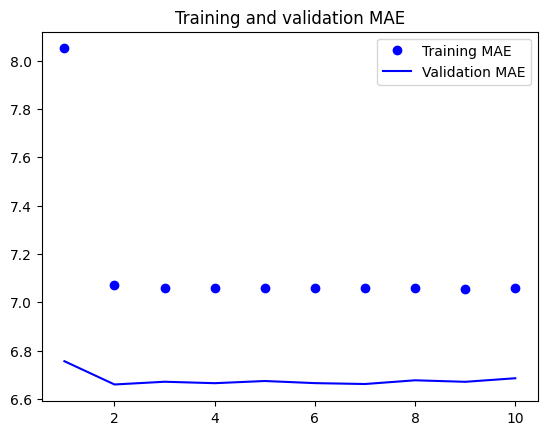

In [13]:
import matplotlib.pyplot as plt
loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

In [14]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 33.6423 - mae: 4.4595 - val_loss: 20.9816 - val_mae: 3.6461
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 18.2027 - mae: 3.4076 - val_loss: 19.7302 - val_mae: 3.5008
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 16.6793 - mae: 3.2540 - val_loss: 20.5901 - val_mae: 3.5841
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 15.7406 - mae: 3.1587 - val_loss: 20.7767 - val_mae: 3.5868
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 14.8813 - mae: 3.0688 - val_loss: 24.2399 - val_mae: 3.8856
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 14.1767 - mae: 2.9954 - val_loss: 21.3068 - val_mae: 3.6226
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 13.5661 - mae: 2.9324 - val_loss: 26.3417 - val_mae: 4.0542
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 13.1431 - mae: 2.8878 - val_loss: 23.4255 - val_mae: 3.7780
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━

In [28]:
for x_batch, y_batch in test_dataset.take(1):
    predictions = model.predict(x_batch)
    break
print("Predicted vs. Actual Temperature (48 Hours Ahead):")
for pred, actual in zip(predictions[:10].flatten(), y_batch.numpy()[:10].flatten()):
    print(f"Predicted: {pred:.2f} °C, Actual: {actual:.2f} °C")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted vs. Actual Temperature (48 Hours Ahead):
Predicted: 11.93 °C, Actual: 10.49 °C
Predicted: -2.42 °C, Actual: -1.65 °C
Predicted: 4.13 °C, Actual: 5.47 °C
Predicted: 12.90 °C, Actual: 10.47 °C
Predicted: 1.53 °C, Actual: 2.27 °C
Predicted: -0.79 °C, Actual: 1.65 °C
Predicted: 17.11 °C, Actual: 6.65 °C
Predicted: 13.18 °C, Actual: 19.51 °C
Predicted: 23.99 °C, Actual: 25.65 °C
Predicted: 8.24 °C, Actual: 5.43 °C


**A simple LSTM-based model**

In [15]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset,
                    callbacks=callbacks)

model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 66.6312 - mae: 6.2698 - val_loss: 17.3904 - val_mae: 3.2492
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 16.8851 - mae: 3.2311 - val_loss: 16.1479 - val_mae: 3.1140
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 15.2350 - mae: 3.0674 - val_loss: 15.7190 - val_mae: 3.0838
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 14.6670 - mae: 3.0032 - val_loss: 15.9053 - val_mae: 3.0999
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - loss: 14.2015 - mae: 2.9514 - val_loss: 16.0947 - val_mae: 3.1169
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 13.7822 - mae: 2.9030 - val_loss: 16.2275 - val_mae: 3.1201
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 13.4626 - mae: 2.8671 - val_loss: 16.6514 - val_mae: 3.1553
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 13.1832 - mae: 2.8332 - val_loss: 17.4681 - val_mae: 3.2060
Epoch 9/10
819/819 ━━━━━

In [29]:
for x_batch, y_batch in test_dataset.take(1):
    predictions = model.predict(x_batch)
    break
print("Predicted vs. Actual Temperature (48 Hours Ahead):")
for pred, actual in zip(predictions[:10].flatten(), y_batch.numpy()[:10].flatten()):
    print(f"Predicted: {pred:.2f} °C, Actual: {actual:.2f} °C")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Predicted vs. Actual Temperature (48 Hours Ahead):
Predicted: 22.73 °C, Actual: 20.33 °C
Predicted: -0.79 °C, Actual: 1.65 °C
Predicted: 11.23 °C, Actual: 15.32 °C
Predicted: 3.55 °C, Actual: 4.98 °C
Predicted: 10.01 °C, Actual: 9.24 °C
Predicted: 13.37 °C, Actual: 14.50 °C
Predicted: 1.31 °C, Actual: 3.91 °C
Predicted: 2.60 °C, Actual: 2.73 °C
Predicted: -4.23 °C, Actual: 0.08 °C
Predicted: 18.09 °C, Actual: 15.92 °C


## Understanding recurrent neural networks

**NumPy implementation of a simple RNN**

In [16]:
import numpy as np
timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features,))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.stack(successive_outputs, axis=0)

### A recurrent layer in Keras

**An RNN layer that can process sequences of any length**

In [17]:
num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

**An RNN layer that returns only its last output step**

In [18]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


**An RNN layer that returns its full output sequence**

In [19]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


**Stacking RNN layers**

In [20]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)

## Advanced use of recurrent neural networks

### Using recurrent dropout to fight overfitting

**Training and evaluating a dropout-regularized LSTM**

In [21]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 356s 432ms/step - loss: 56.1618 - mae: 5.6671 - val_loss: 15.5280 - val_mae: 3.0741
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 370s 452ms/step - loss: 20.9720 - mae: 3.5965 - val_loss: 14.9773 - val_mae: 3.0115
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 347s 424ms/step - loss: 19.5385 - mae: 3.4665 - val_loss: 15.0643 - val_mae: 3.0090
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 318s 388ms/step - loss: 18.9285 - mae: 3.4144 - val_loss: 14.9191 - val_mae: 3.0045
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 275s 335ms/step - loss: 18.2454 - mae: 3.3510 - val_loss: 15.0228 - val_mae: 3.0109
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 280s 341ms/step - loss: 17.8085 - mae: 3.3051 - val_loss: 14.6802 - val_mae: 2.9939
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 277s 338ms/step - loss: 17.5272 - mae: 3.2768 - val_loss: 15.0422 - val_mae: 3.0268
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 247s 302ms/step - loss: 17.0940 - mae: 3.2350 - val_loss: 14.8552 - val_mae: 3.0288
Epoch 9/

In [30]:
for x_batch, y_batch in test_dataset.take(1):
    predictions = model.predict(x_batch)
    break
print("Predicted vs. Actual Temperature (48 Hours Ahead):")
for pred, actual in zip(predictions[:10].flatten(), y_batch.numpy()[:10].flatten()):
    print(f"Predicted: {pred:.2f} °C, Actual: {actual:.2f} °C")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted vs. Actual Temperature (48 Hours Ahead):
Predicted: -2.69 °C, Actual: 3.97 °C
Predicted: 10.73 °C, Actual: 10.76 °C
Predicted: 18.12 °C, Actual: 13.83 °C
Predicted: 21.39 °C, Actual: 24.39 °C
Predicted: 10.22 °C, Actual: 12.40 °C
Predicted: 4.17 °C, Actual: 1.58 °C
Predicted: 14.67 °C, Actual: 14.30 °C
Predicted: 3.01 °C, Actual: 6.91 °C
Predicted: 16.80 °C, Actual: 14.87 °C
Predicted: 4.06 °C, Actual: 7.76 °C


In [22]:
inputs = keras.Input(shape=(sequence_length, num_features))
x = layers.LSTM(32, recurrent_dropout=0.2, unroll=True)(inputs)

### Stacking recurrent layers

**Training and evaluating a dropout-regularized, stacked GRU model**

In [23]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_stacked_gru_dropout.keras",
                                    save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=50,
                    validation_data=val_dataset,
                    callbacks=callbacks)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 541s 658ms/step - loss: 50.2281 - mae: 5.3782 - val_loss: 14.8894 - val_mae: 3.0038
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 533s 650ms/step - loss: 19.9804 - mae: 3.5014 - val_loss: 14.1204 - val_mae: 2.9540
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 503s 614ms/step - loss: 18.6967 - mae: 3.3888 - val_loss: 14.8800 - val_mae: 3.0037
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 526s 642ms/step - loss: 17.7862 - mae: 3.3055 - val_loss: 14.9488 - val_mae: 3.0133
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 501s 612ms/step - loss: 17.0021 - mae: 3.2324 - val_loss: 15.3729 - val_mae: 3.0587
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 498s 608ms/step - loss: 16.4095 - mae: 3.1740 - val_loss: 14.6953 - val_mae: 3.0258
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 502s 612ms/step - loss: 15.9306 - mae: 3.1242 - val_loss: 16.1457 - val_mae: 3.1503
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 499s 609ms/step - loss: 15.4346 - mae: 3.0766 - val_loss: 14.8130 - val_mae: 3.0422
Epoch 9/

In [31]:
for x_batch, y_batch in test_dataset.take(1):
    predictions = model.predict(x_batch)
    break
print("Predicted vs. Actual Temperature (48 Hours Ahead):")
for pred, actual in zip(predictions[:10].flatten(), y_batch.numpy()[:10].flatten()):
    print(f"Predicted: {pred:.2f} °C, Actual: {actual:.2f} °C")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Predicted vs. Actual Temperature (48 Hours Ahead):
Predicted: 13.70 °C, Actual: 8.78 °C
Predicted: 3.70 °C, Actual: -4.28 °C
Predicted: 9.46 °C, Actual: 6.87 °C
Predicted: 3.15 °C, Actual: 0.27 °C
Predicted: 10.09 °C, Actual: 5.15 °C
Predicted: 22.12 °C, Actual: 21.02 °C
Predicted: 11.77 °C, Actual: 15.07 °C
Predicted: 1.95 °C, Actual: 1.22 °C
Predicted: 5.01 °C, Actual: 11.35 °C
Predicted: 2.45 °C, Actual: 4.34 °C


### Using bidirectional RNNs

**Training and evaluating a bidirectional LSTM**

In [24]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 52.1235 - mae: 5.4201 - val_loss: 15.6178 - val_mae: 3.1288
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 14.1460 - mae: 2.9713 - val_loss: 15.9128 - val_mae: 3.1380
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 12.8446 - mae: 2.8251 - val_loss: 16.4599 - val_mae: 3.2039
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 12.0202 - mae: 2.7267 - val_loss: 17.2096 - val_mae: 3.2875
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 11.2528 - mae: 2.6327 - val_loss: 17.6376 - val_mae: 3.3078
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 10.7639 - mae: 2.5703 - val_loss: 16.9109 - val_mae: 3.2533
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 10.2919 - mae: 2.5055 - val_loss: 17.8642 - val_mae: 3.3504
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 9.7436 - mae: 2.4308 - val_loss: 18.8333 - val_mae: 3.4653
Epoch 9/10
819/819 ━━━━━━

In [25]:
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

404/404 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 20.0581 - mae: 3.5599
Test MAE: 3.56


In [32]:
for x_batch, y_batch in test_dataset.take(1):
    predictions = model.predict(x_batch)
    break
print("Predicted vs. Actual Temperature (48 Hours Ahead):")
for pred, actual in zip(predictions[:10].flatten(), y_batch.numpy()[:10].flatten()):
    print(f"Predicted: {pred:.2f} °C, Actual: {actual:.2f} °C")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted vs. Actual Temperature (48 Hours Ahead):
Predicted: 11.04 °C, Actual: 13.83 °C
Predicted: 12.10 °C, Actual: 7.38 °C
Predicted: 9.34 °C, Actual: 6.06 °C
Predicted: 2.42 °C, Actual: -0.03 °C
Predicted: 19.08 °C, Actual: 24.10 °C
Predicted: 5.04 °C, Actual: 1.46 °C
Predicted: 13.79 °C, Actual: 11.75 °C
Predicted: 18.52 °C, Actual: 16.61 °C
Predicted: 19.42 °C, Actual: 22.17 °C
Predicted: 3.58 °C, Actual: 2.66 °C
